In [ ]:
import pandas as pd

EDA

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\ASUS\Downloads\GUvi_projects\Medical\data\Medical_appointment_data.csv")

# Quick overview
print(df.shape)
print(df.info())
print(df.head())


(109593, 26)
<class 'pandas.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   str    
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  str    
 3   no_show                      109593 non-null  str    
 4   disability                   92992 non-null   str    
 5   place                        98054 non-null   str    
 6   appointment_shift            109593 non-null  str    
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 1

In [3]:
#null values
df.isnull().sum()

specialty                      20127
appointment_time                   0
gender                             0
no_show                            0
disability                     16601
place                          11539
appointment_shift                  0
age                            22960
under_12_years_old                 0
over_60_years_old                  0
patient_needs_companion            0
average_temp_day                2211
average_rain_day                2245
max_temp_day                    2227
max_rain_day                    2263
rainy_day_before                   0
storm_day_before                   0
rain_intensity                     0
heat_intensity                     0
appointment_date_continuous        0
Hipertension                       0
Diabetes                           0
Alcoholism                         0
Handcap                            0
Scholarship                        0
SMS_received                       0
dtype: int64

In [5]:
#treating the missing value
# Create a missing flag
df['specialty_missing'] = df['specialty'].isnull().astype(int)
df['specialty'] = df['specialty'].fillna("Other")
df['disability'] = df['disability'].fillna("None")
df['place'] = df['place'].fillna("Unknown")
df['age'] = df['age'].fillna(df['age'].median())

weather_cols = ['average_temp_day','average_rain_day','max_temp_day','max_rain_day']
for col in weather_cols:
    df[col] = df[col].fillna(df[col].median())


In [6]:
df['chronic_conditions'] = df[['Hipertension','Diabetes','Alcoholism','Handcap']].sum(axis=1)


In [7]:
df.duplicated().sum()

np.int64(36)

In [8]:
df.shape

(109593, 28)

In [9]:
df = df.drop_duplicates()



In [10]:
df.shape

(109557, 28)

In [11]:

print(df['gender'].unique())
print(df['no_show'].value_counts())


<ArrowStringArray>
['F', 'M', 'I']
Length: 3, dtype: str
no_show
no     74726
yes    34831
Name: count, dtype: int64


In [12]:
# Clean mapping using .replace() so it won't break if run twice
df['gender'] = df['gender'].replace({'F': 0, 'M': 1, 'I': 0})
df['no_show'] = df['no_show'].replace({'no': 0, 'yes': 1})

# Force the data types to integers
df['gender'] = df['gender'].astype(int)
df['no_show'] = df['no_show'].astype(int)

In [13]:
df.dtypes

specialty                          str
appointment_time                 int64
gender                           int64
no_show                          int64
disability                         str
place                              str
appointment_shift                  str
age                            float64
under_12_years_old               int64
over_60_years_old                int64
patient_needs_companion          int64
average_temp_day               float64
average_rain_day               float64
max_temp_day                   float64
max_rain_day                   float64
rainy_day_before                 int64
storm_day_before                 int64
rain_intensity                     str
heat_intensity                     str
appointment_date_continuous        str
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
Scholarship                      int64
SMS_received             

In [14]:
# Convert to datetime if needed
df['appointment_time'] = pd.to_datetime(df['appointment_time'])
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

# Calculate waiting days
df['DaysWaiting'] = (df['appointment_date_continuous'] - df['appointment_time']).dt.days



In [15]:
df["Weekday"] = df["appointment_date_continuous"].dt.day_name()

In [16]:
#null values
df.isnull().sum()

specialty                      0
appointment_time               0
gender                         0
no_show                        0
disability                     0
place                          0
appointment_shift              0
age                            0
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
average_temp_day               0
average_rain_day               0
max_temp_day                   0
max_rain_day                   0
rainy_day_before               0
storm_day_before               0
rain_intensity                 0
heat_intensity                 0
appointment_date_continuous    0
Hipertension                   0
Diabetes                       0
Alcoholism                     0
Handcap                        0
Scholarship                    0
SMS_received                   0
specialty_missing              0
chronic_conditions             0
DaysWaiting                    0
Weekday                        0
dtype: int

In [17]:
cleaned_df=df

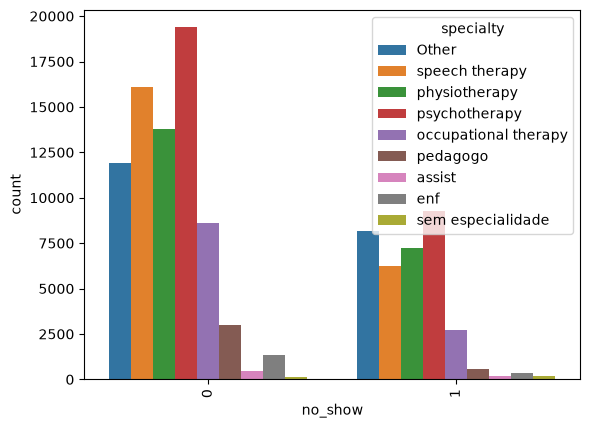

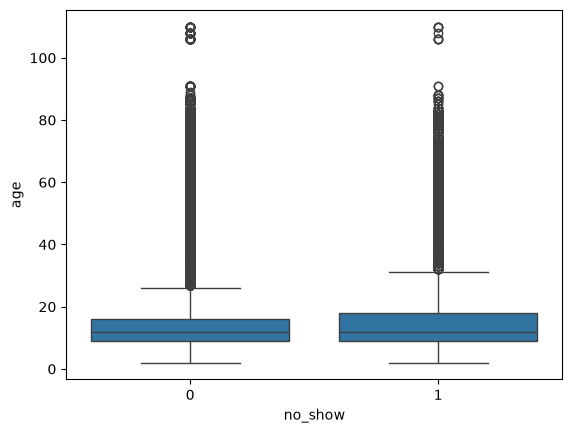

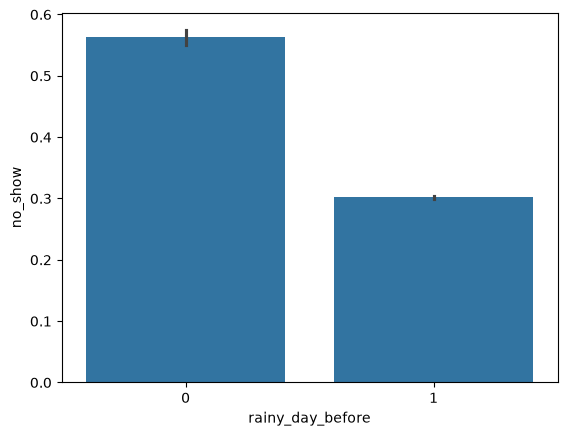

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='no_show', hue='specialty', data=cleaned_df)
plt.xticks(rotation=90)
plt.show()

sns.boxplot(x='no_show', y='age', data=cleaned_df)
plt.show()

sns.barplot(x='rainy_day_before', y='no_show', data=cleaned_df)
plt.show()


In [19]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [45]:
from sklearn.preprocessing import StandardScaler
import numpy as np

In [46]:
X = df[["age","gender","DaysWaiting","Scholarship",
            "Hipertension","Diabetes","Alcoholism","Handcap","chronic_conditions"]]
y = df["no_show"]

    # Split dataset
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

In [49]:
# 2. Scale wide-range continuous numerical variables
continuous_features = ['age', 'DaysWaiting']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

# 3. Handle Class Imbalance by calculating an exact balance weight for XGBoost
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
scale_weight = num_neg / num_pos

In [48]:
x=[]

In [40]:
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

f1 = f1_score(y_test, clf.predict(X_test))
roc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])

In [41]:
x.append(("RandomForestClassifier",f1,roc))

In [28]:
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)

f1 = f1_score(y_test, clf.predict(X_test))
roc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
x.append(("LogisticRegression",f1,roc))

In [26]:
clf = GradientBoostingClassifier()
clf.fit(X_train, y_train)

f1 = f1_score(y_test, clf.predict(X_test))
roc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
x.append(("GradientBoostingClassifier",f1,roc))

In [27]:
clf = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
clf.fit(X_train, y_train)

f1 = f1_score(y_test, clf.predict(X_test))
roc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
x.append(("XGB",f1,roc))

C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [15:59:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#clf = SVC(probability=True, class_weight="balanced")
#clf.fit(X_train, y_train)

#f1 = f1_score(y_test, clf.predict(X_test))
#roc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
#x.append(("SVM",f1,roc))

C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [42]:
print(f"{'Model':<30} | {'f1':<8} | {'roc':<8}")
print("-" * 52)

# Print rows rounded to 4 decimal places
for model, mape, r2 in x:
    print(f"{model:<30} | {mape:<8.4f} | {r2:<8.4f}")

Model                          | f1       | roc     
----------------------------------------------------
RandomForestClassifier         | 0.3235   | 0.5776  
LogisticRegression             | 0.3343   | 0.4962  
GradientBoostingClassifier     | 0.3485   | 0.6288  
XGB                            | 0.3377   | 0.6263  
LogisticRegression             | 0.3343   | 0.4962  
RandomForestClassifier         | 0.3246   | 0.5775  
RandomForestClassifier         | 0.3277   | 0.5777  
RandomForestClassifier         | 0.3278   | 0.5770  


In [30]:
pip install tabulate

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [50]:
models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "RandomForestClassifier": RandomForestClassifier(class_weight='balanced', random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42), # Trees naturally handle imbalance well
    "XGBoost": XGBClassifier(scale_pos_weight=scale_weight, random_state=42, eval_metric='logloss')
}

# 5. Execute the clean evaluation loop
results = []

for name, model in models.items():
    # Fit model on scaled data
    model.fit(X_train_scaled, y_train)
    
    # Get discrete class predictions for F1-Score
    y_pred = model.predict(X_test_scaled)
    
    # Get probability mapping for ROC-AUC
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate proper classification metrics
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append((name, f1, roc))



In [51]:
print(f"{'Model':<30} | {'f1':<8} | {'roc':<8}")
print("-" * 52)

# Print rows rounded to 4 decimal places
for model, mape, r2 in results:
    print(f"{model:<30} | {mape:<8.4f} | {r2:<8.4f}")

Model                          | f1       | roc     
----------------------------------------------------
LogisticRegression             | 0.3964   | 0.5123  
RandomForestClassifier         | 0.4297   | 0.5780  
GradientBoostingClassifier     | 0.3485   | 0.6288  
XGBoost                        | 0.4556   | 0.6266  


In [52]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

In [54]:
daily_counts = cleaned_df.groupby("appointment_date_continuous").size().reset_index(name="y")
daily_counts["dayofweek"] = pd.to_datetime(daily_counts["appointment_date_continuous"]).dt.dayofweek
daily_counts["dayofyear"] = pd.to_datetime(daily_counts["appointment_date_continuous"]).dt.dayofyear

X = daily_counts[["dayofweek","dayofyear"]]
y = daily_counts["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [55]:
results=[]
clf=LinearRegression().fit(X_train, y_train)
y_pred = clf.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results.append(("LinearRegression", mape, r2))

In [56]:
clf=RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results.append(("RandomForestRegressor", mape, r2))

In [57]:
clf=RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results.append(("RandomForestRegressor", mape, r2))

In [58]:
clf=GradientBoostingRegressor().fit(X_train, y_train)
y_pred = clf.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results.append(("GradientBoostingRegressor", mape, r2))

In [59]:
clf=MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
results.append(("MLPRegressor", mape, r2))

C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [60]:
# Print headers
print(f"{'Model':<30} | {'MAPE':<8} | {'R2 Score':<8}")
print("-" * 52)

# Print rows rounded to 4 decimal places
for model, mape, r2 in results:
    print(f"{model:<30} | {mape:<8.4f} | {r2:<8.4f}")

Model                          | MAPE     | R2 Score
----------------------------------------------------
LinearRegression               | 50.0761  | 0.0046  
RandomForestRegressor          | 80.5885  | -0.6123 
RandomForestRegressor          | 80.5885  | -0.6123 
GradientBoostingRegressor      | 80.0630  | -0.4316 
MLPRegressor                   | 40.5937  | -0.0641 
